# 06. Recurrent Neural Networks

<div style="margin:.3rem 0 1rem;font-size:.9em;color:#555;display:flex;align-items:center;gap:.35rem;font-family:monospace">
  <time datetime="2025-05-01">1 May 2025</time> /
  <time datetime="2026-03-25">25 Mar 2026</time>
</div>

<a href="https://colab.research.google.com/github/shahaliyev/csci4701/blob/main/docs/notebooks/06_rnn_sequential.ipynb"
   target="_blank" rel="noopener">
  <img
    src="https://colab.research.google.com/assets/colab-badge.svg"
    alt="Open in Colab"
  />
</a>

<div class="admonition info">
  <p class="admonition-title">Info</p>
  <p style="margin: 0.5em 0;">
    The following sources were consulted in preparing this material:
  <ul style="margin-top: 0;">
    <li>
      Zhang, A., Lipton, Z. C., Li, M., &amp; Smola, A. J. 
      <a href="https://d2l.ai/">Dive into Deep Learning</a>. Cambridge University Press. 
      <a href="https://d2l.ai/chapter_recurrent-neural-networks/index.html">Chapter 9: Recurrent Neural Networks</a>.
    </li>
    <li>
      <a href='https://www.youtube.com/watch?v=TCH_1BHY58I&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=3'>Andrej Karpathy's lecture</a> on <a href='https://github.com/karpathy/makemore'>makemore</a>.
    </li>
  </ul>
  </p>
</div>

Up until this point, our neural network inputs had fixed size (e.g. an image had a fixed height and width). In _sequences_, however, order matters, and the number of steps may vary:

- a sentence is a sequence of words or characters
- a stock signal is a sequence of prices
- a video is a sequence of frames
- a patient history is a sequence of events

This simple change creates a big modeling problem. The number of steps is not known in advance and can vary widely, so the model cannot rely on a different set of parameters for each position in the sequence. 

Imagine designing a model where step 1 uses parameters $W_1$, step 2 uses $W_2$​, step 3 uses $W_3$, and so on. First, the architecture would only work for a fixed sequence length. If the model was built for sequences of length 20, it would simply have no parameters for step 21. Second, learning would become extremely inefficient. Each step-specific parameter would only be trained using data from that particular position in the sequence. The model would have to learn hundreds or thousands of separate rules instead of learning a single general rule that applies everywhere. Third, most sequential processes follow the same underlying dynamics over time. The rule for interpreting the next word in a sentence does not fundamentally change between the beginning and the end of the sentence. Similarly, the physical rules governing motion in video frames are the same at every time step. Because the process itself is repetitive, the model should learn one update rule that can be applied repeatedly.

**Sequence modeling** (unsupervised density modeling) has the goal of estimating the probability distribution of a sequence, $p(\mathbf{x}_1, \ldots, \mathbf{x}_T)$, without predicting a specific target. For the aformentioned reasons, sequence models use parameter sharing across time. The model learns a single function that updates a running summary of the past using the current input. This function is applied again and again as the sequence progresses, allowing the model to process sequences of any length while gradually accumulating information about what has happened so far.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    In sequences the order carries meaning. If we shuffle the words of a sentence, the meaning changes. If we shuffle the frames of a video, the event changes. Images are different: although they can technically be flattened into a sequence of pixels, their natural structure is spatial (a 2D grid).
  </p>
</div>

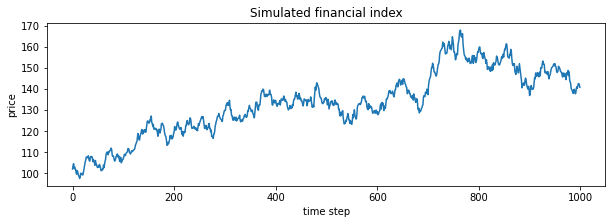

In [530]:
import random
import torch
import matplotlib.pyplot as plt
%matplotlib inline

torch.manual_seed(42)
random.seed(42)

T = 1000
time = torch.arange(T, dtype=torch.float32)

start_price = 100
drift = 0.0003
volatility = 0.01

returns = drift + volatility * torch.randn(T)
price = start_price * torch.exp(torch.cumsum(returns, dim=0))

plt.figure(figsize=(10, 3))
plt.plot(time, price)
plt.title('Simulated financial index')
plt.xlabel('time step')
plt.ylabel('price')
plt.show()

## Autoregressive Modeling

One of the most common sequence tasks is to predict the next value from previous values. This is called [autoregressive modeling](https://en.wikipedia.org/wiki/Autoregressive_model). It appears in many domains, including time series forecasting, language modeling, audio generation, financial prediction, and several classes of generative models. Suppose we observe a sequence of values $x_1, x_2, \dots, x_{t-1}.$ If we want to predict the next value $x_t$, the only available signal may be the past observations themselves. Ideally, we would like to estimate the conditional distribution

$$
P(x_t \mid x_{t-1}, x_{t-2}, \dots, x_1).
$$

In practice, modeling the entire distribution of a continuous variable can be difficult. A common simplification is to estimate a summary statistic, such as the conditional expectation:

$$
\mathbb{E}[x_t \mid x_{t-1}, x_{t-2}, \dots, x_1].
$$

There is an immediate problem, however. The amount of available history grows over time, meaning that the number of input features would continually increase. Standard models such as linear regression or neural networks expect fixed-length input vectors, so directly using the entire past is inconvenient. A simple trick (or rather, compromise) is to use fixed windows. Instead of conditioning on the entire past, we consider only the most recent $\tau$ observations:

$$
\hat{x}_t = f(x_{t-\tau}, \dots, x_{t-1}).
$$

This keeps the number of inputs constant and converts the sequence prediction problem into a standard fixed-input learning problem.

In [531]:
def make_windows(x, tau):
    X, y = [], []
    for t in range(tau, len(x)):
        X.append(x[t - tau:t])
        y.append(x[t])
    return torch.stack(X), torch.tensor(y).unsqueeze(1)

tau = 5
X, y = make_windows(price, tau)

In [532]:
f'Window matrix shape: {X.shape}, Target shape: {y.shape}'

'Window matrix shape: torch.Size([995, 5]), Target shape: torch.Size([995, 1])'

In [533]:
f'First window: {X[0]}, First target: {y[0]}'

'First window: tensor([101.9762, 103.5353, 104.5034, 102.3567, 103.0844]), First target: tensor([101.8502])'

In [534]:
f'Second window: {X[1]}, Second target: {y[0]}'

'Second window: tensor([103.5353, 104.5034, 102.3567, 103.0844, 101.8502]), Second target: tensor([101.8502])'

Instead of predicting directly from the entire history, we approximate the problem by using only the most recent $\tau$ observations. Each window becomes an input vector, and the value immediately following the window becomes the prediction target. For $\tau = 5$, the dataset looks like:

| input window | target |
|---|---|
| $(x_1, x_2, x_3, x_4, x_5)$ | $x_6$ |
| $(x_2, x_3, x_4, x_5, x_6)$ | $x_7$ |
| $(x_3, x_4, x_5, x_6, x_7)$ | $x_8$ |
| $\text{etc.}$ ||

Once the dataset is constructed, we split it into a training and validation portion. Before training, it is also helpful to normalize the data. The following small utility class imitating [`sklearn.preprocessing.StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) performs this standardization by subtracting the mean and dividing by the standard deviation computed from the training data.

In [535]:
class StandardScaler:
    def fit(self, x):
        self.mean = x.mean()
        self.std = x.std()
        
    def transform(self, x):
        return (x - self.mean) / self.std
    
    def inverse(self, x):
        return x * self.std + self.mean

In [536]:
import torch.nn as nn
import torch.nn.functional as F

split = 700
X_train, y_train = X[:split], y[:split]
X_val, y_val = X[split:], y[split:]

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
y_train = scaler.transform(y_train)
y_val = scaler.transform(y_val)

model = nn.Sequential(
    nn.Linear(tau, 32),
    nn.Tanh(),
    nn.Linear(32, 1)
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

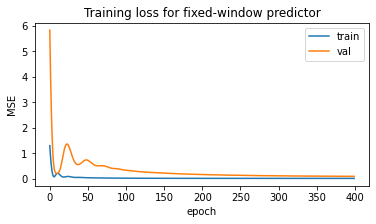

In [537]:
train_losses = []
val_losses = []

for epoch in range(400):
    model.train()
    pred = model(X_train)
    loss = F.mse_loss(pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val)
        val_loss = F.mse_loss(val_pred, y_val)
        
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

plt.figure(figsize=(6, 3))
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.title('Training loss for fixed-window predictor')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

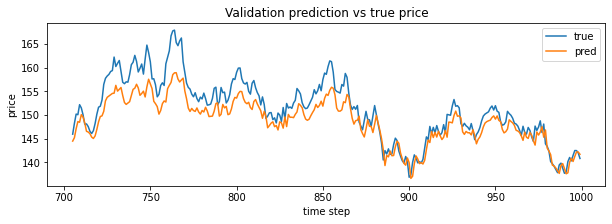

In [538]:
with torch.no_grad():
    pred_val = model(X_val)

pred_val = scaler.inverse(pred_val)
y_val_true = scaler.inverse(y_val)

plt.figure(figsize=(10, 3))
plt.plot(range(split + tau, split + tau + len(y_val_true)), y_val_true.squeeze(), label='true')
plt.plot(range(split + tau, split + tau + len(pred_val)), pred_val.squeeze(), label='pred')
plt.title('Validation prediction vs true price')
plt.xlabel('time step')
plt.ylabel('price')
plt.legend()
plt.show()

The plot above shows the model's one-step predictions compared to the true price sequence on the validation portion of the data. The network is able to capture the general movement of the signal, but its predictions appear noticeably smoother than the true sequence. This happens because the model is trained with mean squared error. When the next value is uncertain, the safest prediction is often a value close to the local average of the recent observations.

Another important limitation comes from the way we constructed the dataset. The model only receives the last $\tau$ values as input. Any information that occurred earlier than this window is completely ignored. In other words, the model has a _fixed memory_ of length $\tau$. While the window approach allows us to use standard neural networks with fixed-size inputs, it is only an approximation to the original autoregressive problem or predicting the distribution.


<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
  Using a fixed window can also be interpreted as making a <a href="https://en.wikipedia.org/wiki/Markov_property">Markov assumption</a>. Instead of conditioning on the entire history, we assume that the next value depends only on the most recent $\tau$ observations:
  $$
  P(x_t \mid x_1,\dots,x_{t-1}) \approx P(x_t \mid x_{t-\tau},\dots,x_{t-1}).
  $$
  
  This is known as a <strong>$\boldsymbol{\tau}$-order Markov assumption</strong>. For the first-order Markov (the window size $\tau = 1$), it leads to:
  $$
  P(x_t \mid x_1,\dots,x_{t-1}) \approx P(x_t \mid x_{t-1}).
  $$
  
  In practice this assumption is rarely exactly true, but the influence of distant history often diminishes. Using a finite window therefore provides a practical approximation that can allow us to train models with fixed-size inputs.
  </p>
</div>

We now may attempt for a multi-step prediction. Unlike one-step  prediction (as above), where the model always receives the true previous values, rollout forecasting feeds the model's own predictions back as future inputs. This makes the task much harder. Any small prediction error becomes part of the next input window, so errors can accumulate over time and the predicted trajectory may drift away from the true sequence. Later on, we will see how we can tackle this problem.

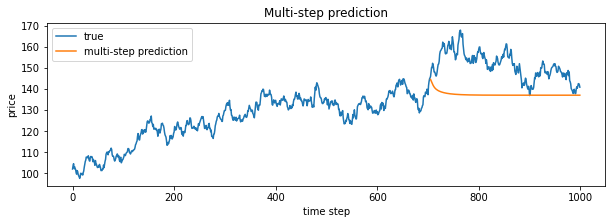

In [539]:
with torch.no_grad():
    rollout = scaler.transform(price.clone())

    for t in range(split + tau, T):
        window = rollout[t - tau:t]
        rollout[t] = model(window.unsqueeze(0)).squeeze()

rollout = scaler.inverse(rollout)

plt.figure(figsize=(10, 3))
plt.plot(time, price, label='true')
plt.plot(time[split + tau:], rollout[split + tau:], label='multi-step prediction')
plt.legend()
plt.title('Multi-step prediction')
plt.xlabel('time step')
plt.ylabel('price')
plt.show()

## Language Modeling

Language modeling is the task of predicting the next word (or token) in a sequence based on the words that come before it. The model learns patterns in text so it can estimate how _likely_ different sequences of words are. In most cases it is autoregressive, meaning the model generates text one token at a time using the previously generated tokens as context.  A **token** is simply the atomic unit the model works with. Depending on the choice, a token can be a word, subword, character, etc. We will use character-level tokens for studying the sequence models in a simple and clear manner. A text sequence can be written as a list of tokens:

$x_1, x_2, x_3, \dots, x_T$,

where each $x_t$ is one token observed at time step $t$. The goal of a language model is to assign a probability to an entire sequence:

$P(x_1, x_2, \dots, x_T)$.

Once we know how to assign probabilities to sequences, we get several useful things automatically:

- we can compare which sentence is more plausible,
- we can generate text by sampling one token at a time,
- we can train models by rewarding high probability on the correct next token.

The [chain rule of probability](../../mathematics/03_probability/#chain-rule) is helpful to turn language modeling into a next-token prediction problem:

<div style="overflow-x:auto; max-width:100%">
$$
P(x_1, x_2, \dots, x_T)
=
P(x_1)\,P(x_2 \mid x_1)\,P(x_3 \mid x_1,x_2)\cdots P(x_T \mid x_1,\dots,x_{T-1})
$$
</div>

Instead of trying to learn the whole sequence probability in one shot, we learn to repeatedly answer the question: _given the tokens so far, what should come next?_ To experiment with language models we need a dataset of sequences.

In [540]:
import requests
import random

def load_names(source='makemore_aze', shuffle=True):
    urls = {
        'makemore': 'https://raw.githubusercontent.com/karpathy/makemore/master/names.txt',
        'female':   'https://raw.githubusercontent.com/aznlp/names/master/female.txt',
        'male':     'https://raw.githubusercontent.com/aznlp/names/master/male.txt',
    }
    if source == 'makemore':
        words = requests.get(urls['makemore']).text.splitlines()
    elif source == 'makemore_aze':
        female = requests.get(urls['female']).text.splitlines()
        male = requests.get(urls['male']).text.splitlines()
        words = female + male
        words = list(dict.fromkeys(words))  # remove duplicates, preserve order
    elif source == 'female':
        words = requests.get(urls['female']).text.splitlines()
    elif source == 'male':
        words = requests.get(urls['male']).text.splitlines()
    else:
        raise ValueError("source must be 'makemore', 'male', 'female', or 'makemore_aze'")

    words = [w.strip().lower() for w in words if w.strip()]

    if shuffle and source != 'makemore':
        random.shuffle(words)

    return words

In [541]:
words = load_names('makemore')

f'Number of names: {len(words)}. The first five words: {words[:5]}'


"Number of names: 32033. The first five words: ['emma', 'olivia', 'ava', 'isabella', 'sophia']"

Each element in `words` is a single name represented as a Python string. Since we will build a character-level language model, we need to work with the individual characters that appear in the dataset. The first step is to determine the **vocabulary**, i.e. the set of unique characters used across all names. We construct it by joining all names into one long string and taking the set of characters. Sorting the result makes the ordering deterministic, which is convenient for reproducibility. The vocabulary size is simply the total number of distinct tokens the model can produce.

Language models operate on numeric indices, not raw characters, so we create two lookup tables:

- `stoi` (string → index): maps each character to a unique integer.
- `itos` (index → string): the inverse mapping that lets us convert indices back to characters.

We also introduce a special token `.` that marks the start and end of a sequence. This token allows the model to learn which characters tend to begin names and when a name should terminate. 

In [ ]:
chars = sorted(list(set(''.join(words))))
stoi = {ch: i + 1 for i, ch in enumerate(chars)}
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}
VOCAB_SIZE = len(stoi)

f'Vocabulary size: {VOCAB_SIZE}. STOI: {stoi}'


"Vocabulary size: 27. STOI: {'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}"

In [543]:
example = words[0]
encoded = [stoi[ch] for ch in example] + [stoi['.']]

f'Name: "{example}" Encoded: {encoded} Decoded: "{"".join(itos[i] for i in encoded)}"'

'Name: "emma" Encoded: [5, 13, 13, 1, 0] Decoded: "emma."'

Before building a model, it is useful to inspect some basic statistical properties of the dataset itself. It turns out the natural language is not distributed uniformly: a small number of tokens appear very often, while many others are rare. A famous empirical pattern describing such behavior is [Zipf's law](https://en.wikipedia.org/wiki/Zipf%27s_law)<span class="fn"><span class="fn-body"> A [scientific law](https://en.wikipedia.org/wiki/Scientific_law) typically refers to a precise, universally valid relationship that holds under well-defined conditions (for example, Newton's laws of motion or the laws of thermodynamics). Such laws are expected to be stable, reproducible, and grounded in a clear theoretical framework. In contrast, Zipf's law is *empirical*: it describes a pattern that is often observed in real data (especially language), but it is not exact, not universal, and does not arise from a single agreed-upon theory. A similar case is infamous [Moore's law](https://en.wikipedia.org/wiki/Moore%27s_law), which describes the growth of transistor counts in integrated circuits over time.</span></span> If we rank tokens by frequency, then the frequency of the token with rank $i$ is often approximately

$$
n_i \propto \frac{1}{i^\alpha},
$$

where $n_i$ is the frequency and $\alpha$ is a positive constant. Even though our dataset is small and consists of names rather than full natural language text, we can still examine whether the character distribution has a similar long-tail shape. This helps build intuition for an important fact: language data is highly imbalanced, and rare events quickly become a problem for pure counting methods.

In [544]:
from collections import Counter

counts = Counter(''.join(words))

print("Top characters:")
for ch, f in counts.most_common(10):
    print(f"{repr(ch):>4} : {f}")

Top characters:
 'a' : 33885
 'e' : 20423
 'n' : 18327
 'i' : 17701
 'l' : 13958
 'r' : 12700
 'y' : 9776
 's' : 8106
 'o' : 7934
 'h' : 7616


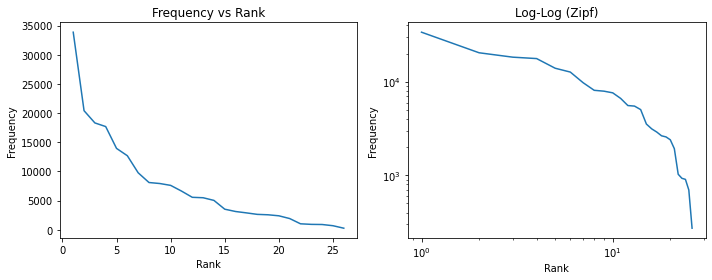

In [545]:
import numpy as np

freqs = np.array(sorted(counts.values(), reverse=True))
ranks = np.arange(1, len(freqs) + 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(ranks, freqs)
ax[0].set_title("Frequency vs Rank")
ax[0].set_xlabel("Rank")
ax[0].set_ylabel("Frequency")

ax[1].plot(ranks, freqs)
ax[1].set_xscale("log")
ax[1].set_yscale("log")
ax[1].set_title("Log-Log (Zipf)")
ax[1].set_xlabel("Rank")
ax[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

To make the structure of Zipf's law visible, we take logarithms:

$$
\log n_i = -\alpha \log i + c.
$$

If Zipf’s law holds, the curve should appear approximately as a straight line with negative slope. As you can see, in our dataset, the log-log plot is not perfectly linear. This is expected, as the dataset is small (only names), we are working with characters, not words, and the rare characters introduce noise in the tail. Zipf's law becomes much clearer when we work on larger and more diverse datasets:

Before building a model, it is useful to inspect how characters follow one another in the dataset. The simplest possible language model is a **bigram model**, which assumes that the probability of the next character depends only on the previous character. Instead of using the full history, the bigram model approximates it with

$P(x_t \mid x_{t-1})$.

This is exactly _first-order Markov assumption_: the most recent token is treated as the only relevant context for predicting the next token. To estimate these probabilities from data, we count how often each character follows another. For every name we insert the boundary token `.` at the beginning and end:

`. → a`, `a → n`, `n → n`, `n → a`, `a → .`.

By collecting such transitions across the entire dataset, we can build a count matrix where each entry records how often one character is followed by another. This matrix will be the basis of our first language model.

In [546]:
N = torch.zeros((len(stoi), len(stoi)), dtype=torch.int32)
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        i = stoi[ch1]
        j = stoi[ch2]
        N[i, j] += 1
    
N[:5, :5]

tensor([[   0, 4410, 1306, 1542, 1690],
        [6640,  556,  541,  470, 1042],
        [ 114,  321,   38,    1,   65],
        [  97,  815,    0,   42,    1],
        [ 516, 1303,    1,    3,  149]], dtype=torch.int32)

The matrix `N` stores how often one character is followed by another. Each row corresponds to the current character and each column corresponds to the next character. For example, the entry `N[i, j]` counts how many times character `j` appeared immediately after character `i` in the dataset. To make this easier to understand, we can visualize the matrix. To make the matrix interpretable, we can annotate it with the actual characters and the counts inside each cell. This allows us to directly read transitions such as how often `a → n` or `n → a` occurs in the dataset.

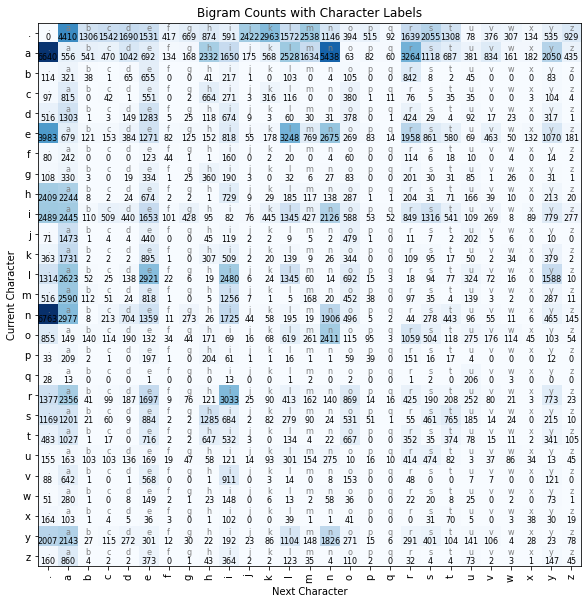

In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(N, cmap='Blues')

for i in range(VOCAB_SIZE):
    for j in range(VOCAB_SIZE):
        plt.text(j, i, itos[j], ha='center', va='bottom', fontsize=8, color='gray')
        plt.text(j, i, int(N[i, j].item()), ha='center', va='top', fontsize=8)

plt.xticks(range(VOCAB_SIZE), [itos[i] for i in range(VOCAB_SIZE)], rotation=90)
plt.yticks(range(VOCAB_SIZE), [itos[i] for i in range(VOCAB_SIZE)])
plt.xlabel('Next Character')
plt.ylabel('Current Character')
plt.title('Bigram Counts with Character Labels')
plt.show()

The count matrix tells us how often each transition occurs, but a language model needs probabilities, not raw counts. To convert counts into probabilities, we normalize each row of the matrix so that the values sum to 1. After normalization, every row represents a probability distribution over the possible next characters.

However, one issue remains: if a transition never appears in the dataset, its count will be zero. This assigns the transition probability zero. Since the probability of a sequence is computed as a product of such terms, a single zero makes the entire sequence probability zero. To avoid this, we apply [additive (Laplace) smoothing](https://en.wikipedia.org/wiki/Additive_smoothing), which adds a small constant $\alpha$ to every count:

$$
P_{ij} = \frac{N_{ij} + \alpha}{\sum_k (N_{ik} + \alpha)}
$$

This ensures that no transition has zero probability. In this notebook, we use the simplest case $\alpha = 1$. This is not always optimal in practice, but it is sufficient here to avoid zero probabilities and keep the model well-defined.

In [548]:
P = (N + 1).float()
P = P / P.sum(dim=1, keepdim=True)

row = stoi['a']
for j in torch.topk(P[row], 5).indices.tolist():
    print(f"P(next='{itos[j]}' | current='a') = {P[row, j]:.4f}")


P(next='.' | current='a') = 0.1958
P(next='n' | current='a') = 0.1604
P(next='r' | current='a') = 0.0963
P(next='l' | current='a') = 0.0746
P(next='h' | current='a') = 0.0688


To generate text from the model, we do not always pick the most probable next character. Instead, we **sample** from the probability distribution. This means more likely characters are chosen more often, but less likely ones can still appear occasionally. PyTorch provides `torch.multinomial` for this purpose. Given a probability vector, it returns an index sampled according to those probabilities. This is why the same model can generate different names each time we run it.

In [549]:
p = torch.tensor([0.7, 0.2, 0.1])
samples = torch.multinomial(p, num_samples=10, replacement=True)

f'Probabilities: {p.tolist()}'

'Probabilities: [0.699999988079071, 0.20000000298023224, 0.10000000149011612]'

In [550]:
f'Sampled indices: {samples.tolist()}'

'Sampled indices: [1, 2, 0, 0, 0, 0, 0, 0, 0, 0]'

Once we have the probability matrix `P`, we can generate new names by sampling characters one at a time. We begin with the start token `.`. The row corresponding to the current character gives a probability distribution over the possible next characters, and we randomly sample from that distribution. The sampled character becomes the new current character, and the process repeats. Generation stops when the model produces the boundary token `.` again. This means the model decided the sequence should end. Because the sampling is probabilistic, the model can generate many different names, even though it was trained on a fixed dataset.

In [551]:
num_samples = 10
g = torch.Generator().manual_seed(42)

names = []
for _ in range(num_samples):
    out = []
    ix = 0
    while True:
        ix = torch.multinomial(P[ix], num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    names.append(''.join(out))
names    

['ya.',
 'syahavilin.',
 'dleekahmangonya.',
 'tryahe.',
 'chen.',
 'ena.',
 'da.',
 'amiiae.',
 'a.',
 'keles.']

So far the model has learned how to generate names by sampling from the learned transition probabilities. But a language model should also be able to evaluate sequences. In other words, given a sequence of characters, how likely does the model think that sequence is? Under the bigram model, the probability of a sequence is computed by multiplying the conditional probabilities of each transition. For a name like `anna`, the sequence becomes `. a n n a .`, and its probability is

$P(a \mid .)\,P(n \mid a)\,P(n \mid n)\,P(a \mid n)\,P(. \mid a)$.

Because probabilities are small numbers, multiplying many of them quickly produces extremely tiny values. To make computation stable and easier to interpret, we work in log-space, adding log-probabilities instead of multiplying probabilities.

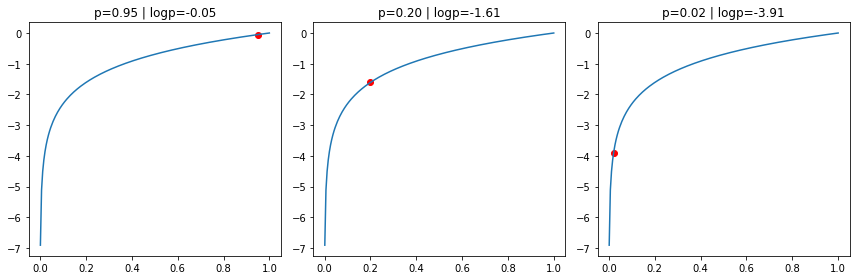

In [552]:
p = torch.linspace(0.001, 1.0, 200)
log_p = torch.log(p)

def plot_logp(p1, p2, p3):
    fig, ax = plt.subplots(1, 3, figsize=(12,4))
    for a, pv in zip(ax, [p1, p2, p3]):
        y = torch.log(torch.tensor(pv)).item()
        a.plot(p, log_p)
        a.scatter([pv], [y], color='red')
        a.set_title(f'p={pv:.2f} | logp={y:.2f}')
    plt.tight_layout(); plt.show()

plot_logp(0.95, 0.2, 0.02)

The plot shows how probabilities are transformed by the logarithm. Values close to 1 map to values near 0, while small probabilities map to large negative values. This makes the scale more informative: confident predictions (high probability) stay near 0, while unlikely predictions are pushed far down. In practice, probabilities can sometimes be exactly 0, and $\log(0)$ is undefined (it goes to $-\infty$). This is another reason we avoid zero probabilities (e.g. with smoothing) and prefer working in log-space, which is more stable when combining many probabilities.

In [553]:
example = words[0]
chs = ['.'] + list(example) + ['.']

logp = 0.0
transitions = []

for ch1, ch2 in zip(chs, chs[1:]):
    i = stoi[ch1]
    j = stoi[ch2]
    p = P[i, j].item()
    logp += torch.log(P[i, j]).item()
    transitions.append((f'{ch1} -> {ch2}', p))


f'Log-probability: {logp}.'

'Log-probability: -12.571641862392426.'

The function above computes the log-probability of a name under the bigram model. For each pair of consecutive characters, it looks up the corresponding probability in the matrix `P`. Instead of multiplying all transition probabilities directly, it adds their logarithms. This is mathematically equivalent, but much more stable numerically. The `transitions` list is included only for inspection: it shows each character-to-character step together with its probability. The final `logp` value summarizes how plausible the whole name is according to the model. Higher log-probability means the sequence is considered more _likely_.

To evaluate the model more systematically, we compute the average **negative log-likelihood (NLL)** over the dataset. For every transition in every name, we take the negative logarithm of the probability assigned by the model and average these values. Lower NLL means the model assigns higher probability to the observed data, which indicates a better fit.

<div class="admonition warning">
  <p class="admonition-title">Important</p>
  <p style="margin: 1em 0;">
  The average NLL is exactly the <a href='../../mathematics/04_information/#cross-entropy'>cross-entropy</a> between the empirical data distribution and the model distribution.
  
  In other words, it measures how many "nats" (or bits, if using base-2 logarithms) are required on average to encode the data when using the model's probabilities. If the model perfectly matched the true data distribution, this value would reduce to the <a href='../../mathematics/04_information/#entropy'>Shannon entropy</a>, which represents the inherent uncertainty of the data itself. In practice, NLL is higher than entropy because the model is only an approximation.
  </p>
</div>

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
  We compute NLL as an average over the dataset:
  
  $$ \frac{1}{N} \sum_{i=1}^N -\log Q(x_i), $$
  
  while cross-entropy is defined theoretically as
  
  $$ -\sum_x P(x)\log Q(x). $$
  
  These are the same quantity: the dataset average is an empirical estimate of the expectation under the true (unknown) data distribution $P$.
  </p>
</div>

<div class="admonition tip">
  <p class="admonition-title">Tip</p>
  <p style="margin: 1em 0;">
    We have alredy discussed negative log-likelihood and related concepts in <a href='../../mathematics/05_prob_modeling/#negative-log-likelihood'>probabilistic modeling</a>. 
  </p>
</div>

A commonly reported metric derived from NLL is **perplexity**, defined as

$$ \text{Perplexity} = e^{\text{NLL}} = e^{H(P, Q)}, $$

where $H(P, Q)$ denotes the cross-entropy between the data distribution $P$ and the model distribution $Q$. Perplexity can be understood as the *effective number of equally likely choices* the model is uncertain between when predicting the next token. For example, a perplexity of 5 suggests that the model behaves as if it were choosing among roughly five equally probable characters at each step.

This interpretation comes from the following observation. If the model assigned equal probability to $k$ possible tokens, then the probability of the correct token would be $1/k$. The negative log-likelihood would be $\log k$, and exponentiating it gives $k$, which matches the perplexity. In practice, model probabilities are not uniform, so this should be seen as an intuitive approximation. Lower perplexity therefore indicates a stronger language model, as it reflects higher probability assigned to the correct next tokens and reduced uncertainty in predictions.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    Perplexity became standard in language modeling because it converts log-based quantities (e.g. cross-entropy), which are difficult to interpret directly, into a more intuitive scale. Instead of abstract logarithmic values, it returns an effective number of choices, making it easier for humans to compare models and reason about uncertainty.
  </p>
</div>

In [554]:
total = 0.0
count = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        i = stoi[ch1]
        j = stoi[ch2]
        total += -torch.log(P[i, j]).item()
        count += 1

nll = total / count
perplexity = torch.exp(torch.tensor(nll)).item()

f'Average negative log-likelihood: {nll:.4f} / Perplexity: {perplexity:.4f}'

'Average negative log-likelihood: 2.4546 / Perplexity: 11.6415'

The bigram model is useful because it is simple, interpretable, and easy to build directly from counts. It can already capture basic local structure such as which characters tend to start names and which characters commonly follow others. However, it has a major limitation: every prediction depends only on the immediately previous character. This means the model treats all contexts ending in the same character as identical. For example, if the current character is `a`, the model always uses the same next-character distribution, regardless of whether the preceding sequence was `ma`, `la`, or `anna`. In other words, it has no memory beyond one step.

To model richer patterns, we need a method that can use more **context**. One possibility is to extend the idea from bigrams to trigrams or, more generally, to **n-gram models**, where the next token depends on the previous $n-1$ tokens. This gives the model more information, but it also increases the number of possible contexts dramatically. Many contexts become rare or never appear at all, which makes pure counting methods increasingly inefficient. So the next step is to keep the same next-token prediction framework, but allow the model to condition on a longer context in a more flexible way.

The vanilla bigram model also has a limitation  of entirley being based on counting. The model cannot improve beyond the data it has seen, and it does not generalize to unseen or rare patterns. Instead, we can move to a different idea where we _learn_ the probabilities. Rather than storing counts, we will assign a set of learnable parameters that produce scores for each possible next character. These scores are called **logits**. Given a current character $i$, the model will output a vector, where each value represents how strongly the model prefers a particular next character. These logits will be converted to probabilities via the [softmax function](../../mathematics/03_probability/#softmax).

## Neural N-gram Language Models

One way to extend the bigram idea is to increase the amount of context used for prediction. Instead of conditioning only on the previous character, we can condition on the previous multiple characters:

$P(x_t \mid x_{t-n+1}, \dots, x_{t-1})$.

This is exactly _k-th order Markov assumption_. Using more context can improve predictions, but we mentioned that pure count-based methods quickly become impractical. The number of possible contexts grows exponentially with the context length, and many combinations appear rarely or never in the dataset. Therefore, a more flexible approach is to let a neural network learn how to use the context. Instead of storing large count tables, we convert the previous characters into vectors and train a small neural network to predict the next character.

The overall idea remains exactly the same as before: given a context of previous tokens, the model outputs a probability distribution over the next token. The difference is that the probabilities are produced by a learned neural network rather than by counting transitions in a table.

To train a neural n-gram model, we must convert the dataset into input–target pairs. Each training example consists of a fixed-length context and the character that follows it. Suppose the context length is 3. For the name `anna`, with boundary tokens added, the training pairs become:

| Context | Target |
|--------|--------|
| `. . .` | `a` |
| `. . a` | `n` |
| `. a n` | `n` |
| `a n n` | `a` |
| `n n a` | `.` |

Here the context always contains the previous three characters, and the model learns to predict the next character that follows that context. These will become the inputs and targets for training the neural network.

In [555]:
def build_dataset(words, block_size=3):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in list(w) + ['.']:
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    return torch.tensor(X), torch.tensor(Y)

In [556]:
BLOCK_SIZE = 3

X, Y = build_dataset(words, BLOCK_SIZE)
f'X shape: {tuple(X.shape)} | Y shape: {tuple(Y.shape)}'

'X shape: (228146, 3) | Y shape: (228146,)'

Each row in `X` represents a context of previous characters, encoded as integer token ids, while the corresponding entry in `Y` is the target character the model should predict. For example, if a row in `X` is `[0, 0, 1]`, it represents the context `., ., a`. The corresponding value in `Y` might be `13`, which maps to some character such as `n`. During training, the model receives the context `[0, 0, 1]` and learns to assign high probability to the correct next character. Inspecting a few examples helps verify that the dataset was constructed correctly.

In [557]:
[( [itos[i] for i in X[k].tolist()], itos[Y[k].item()] ) for k in range(10)]

[(['.', '.', '.'], 'e'),
 (['.', '.', 'e'], 'm'),
 (['.', 'e', 'm'], 'm'),
 (['e', 'm', 'm'], 'a'),
 (['m', 'm', 'a'], '.'),
 (['.', '.', '.'], 'o'),
 (['.', '.', 'o'], 'l'),
 (['.', 'o', 'l'], 'i'),
 (['o', 'l', 'i'], 'v'),
 (['l', 'i', 'v'], 'i')]

### Embeddings

Neural networks require continuous vector inputs, so we cannot use raw token indices directly. Instead, we map each token to a learned dense vector representation called an **embedding**.

The well-known [one-hot](https://en.wikipedia.org/wiki/One-hot) encoding represents each token as a vector of length equal to the vocabulary size, with a single 1 at the token’s position and 0s elsewhere. For small vocabularies, this is manageable. However, as the vocabulary grows (e.g. 10,000 words), one-hot vectors become extremely large and inefficient: they waste memory, require unnecessary computation, and contain no notion of similarity. Any two one-hot vectors are orthogonal, so their dot product is always 0.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    One might ask: why not just use integer indices directly (e.g. $'b' \rightarrow 2$)? This is also problematic, because indices introduce a false sense of order and distance (recall the ordinal/categorical variables from a course on statistics). The model may interpret token 3 as being "closer" to token 2 than to token 10, even though tokens are purely categorical and have no inherent ordering. This creates an incorrect inductive bias. 
  </p>
</div>

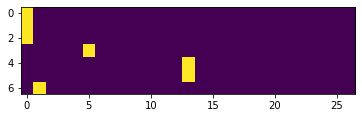

In [558]:
import torch.nn.functional as F

chs = ['.'] * BLOCK_SIZE + list(words[0]) # "...emma"

ix = torch.tensor([stoi[c] for c in chs])
x_onehot = F.one_hot(ix, num_classes=VOCAB_SIZE).float()

plt.imshow(x_onehot)

We therefore need a representation that is both compact and meaningful. Embeddings provide exactly this: each token is mapped to a dense vector that can be learned from data. Embeddings are equivalent to one-hot encoding followed by a matrix multiplication. If a token is represented by a one-hot vector $x$ and multiplied by a weight matrix $C$, the result simply selects one row of that matrix:

$$
x C = C[i]
$$

where $i$ is the index of the active entry. In practice, we skip constructing the one-hot vector and directly retrieve the corresponding row using `C[X]`. This is mathematically identical, but far more efficient. An embedding matrix $C \in \mathbb{R}^{V \times d}$ maps each token index to a dense vector of dimension $d$, where $V$ is the vocabulary size. These embeddings are parameters of the model: they are initialized randomly and updated during training to reflect how tokens are used in context.

For example, consider the contexts:
- $['b', 'a', 'd', 'a'] \rightarrow 'm'$
- $['m', 'a', 'd', 'a'] \rightarrow 'm'$

To correctly predict the same target in both cases, the model is encouraged to learn similar representations for $'b'$ and $'m'$. More generally, tokens that appear in similar contexts will have embeddings that move closer together during training.

The embedding dimension $d$ controls how much information each token representation can carry. Here we use $d = 2$, which is sufficient for a small dataset and allows easy visualization. However, this is a simplification: if $d$ is too small, the model cannot represent enough structure, if it is too large, it may overfit and require more data and computation. In larger language models, embedding dimensions are typically much higher to capture more detailed relationships.

In [ ]:
EMBED_DIM = 2

C = torch.randn((VOCAB_SIZE, EMBED_DIM))

C[X].shape

torch.Size([228146, 3, 2])

Each context now consists of several embedding vectors — one for each character in the context. Unlike one-hot encodings, embeddings are learned and allow the model to represent similarities between characters, so similar contexts can share statistical strength. Before passing them to a neural network, we typically flatten these vectors into a single feature vector so the network can process the entire context together. The flattened embedding vectors will represent the input features for the neural network. The next step is to map these features to scores for each possible next character. We do this with a simple linear layer.

In [ ]:
emb = C[X]                     
emb_flat = emb.view(emb.shape[0], -1)

W1 = torch.randn((BLOCK_SIZE * EMBED_DIM, VOCAB_SIZE))
b1 = torch.randn(VOCAB_SIZE)

logits = emb_flat @ W1 + b1
logits.shape

torch.Size([228146, 27])

We already know that the values in `logits` are scores produced by the neural network for each possible next character. Larger values indicate that the model considers that character more likely, but these scores are not yet probabilities. To convert logits into probabilities, we apply the [softmax](../../mathematics/03_probability/#softmax) function. As softmax function relies on exponentiation, let's discuss it briefly. 

The exponential function has two important properties that make it suitable for converting logits into probabilities: it is always positive, $e^x > 0$ for all $x$, and small increases in $x$ lead to large increases in $e^x$:
- $e^1 \approx 2.7$
- $e^2 \approx 7.4$
- $e^3 \approx 20$.

This means that slightly larger logits become disproportionately larger after exponentiation, allowing the model to express strong preferences between tokens. Similar to the logirthm function, exponentiation preserves ordering. 

In [561]:
def softmax(logits):
    logits = logits - logits.max(dim=1, keepdim=True).values # to avoid numerical overflow
    exp_logits = torch.exp(logits)
    return exp_logits / exp_logits.sum(dim=1, keepdim=True)

probs = softmax(logits)
probs.shape, probs[0].sum()

(torch.Size([228146, 27]), tensor(1.0000))

For each training example, the model produces a probability distribution over the vocabulary. The correct next character for that example is stored in `Y`. To measure how well the model predicts the correct characters, we compute the NLL of those probabilities to define our loss.

In [562]:
loss = -torch.log(probs[torch.arange(X.shape[0]), Y]).mean()

f'Initial loss: {loss.item():.4f}'

'Initial loss: 7.2687'

The loss above measures how well the model predicts the correct next characters. This loss is exactly the _cross-entropy loss_ used in classification. In practice, it is often implemented in a more numerically stable way by combining the softmax and logarithm into a single function. To improve the predictions, we will apply gradient descent. 

<div class="admonition info">
  <p class="admonition-title">Info</p>
  <p style="margin: 1em 0;">
    The idea of learning word representations jointly with a neural language model was popularized by <a href="https://www.jmlr.org/papers/volume3/bengio03a/bengio03a.pdf">Bengio et al. (2003)</a>. This work introduced the use of embeddings and feedforward neural networks for language modeling, laying the foundation for many modern approaches.
  </p>
</div>

In [563]:
BLOCK_SIZE = 3

X, Y = build_dataset(words, BLOCK_SIZE)

In [ ]:
HIDDEN_SIZE = 100 # layer size

# trainable parameters
C = torch.randn((VOCAB_SIZE, EMBED_DIM), requires_grad=True)
W1 = torch.randn((BLOCK_SIZE * EMBED_DIM, HIDDEN_SIZE), requires_grad=True)
b1 = torch.randn(HIDDEN_SIZE, requires_grad=True)
W2 = torch.randn((HIDDEN_SIZE, VOCAB_SIZE), requires_grad=True)
b2 = torch.randn(VOCAB_SIZE, requires_grad=True)

params = [C, W1, b1, W2, b2]

In [565]:
def forward_pass(X, params):
    C, W1, b1, W2, b2 = params
    emb = C[X]
    emb_flat = emb.view(X.shape[0], -1)
    h = torch.tanh(emb_flat @ W1 + b1)
    logits = h @ W2 + b2
    return logits


def train_step(X, Y, params, optimizer):
    logits = forward_pass(X, params)
    loss = F.cross_entropy(logits, Y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    return loss

def eval_loss(X, Y, params):
    with torch.no_grad():
        logits = forward_pass(X, params)
        loss = F.cross_entropy(logits, Y)
    return loss

def print_progress(e, epochs, loss, print_every=10):
    if (e + 1) % print_every == 0:
        print(f'[{e+1}/{epochs}] | Loss: {loss.item():.4f}')

In [566]:
epochs = 100
lr = 0.001

optimizer = torch.optim.Adam(params, lr=lr)

In [567]:
for e in range(epochs):
    loss = train_step(X, Y, params, optimizer)
    print_progress(e, epochs, loss)

[10/100] | Loss: 16.3297
[20/100] | Loss: 15.1789
[30/100] | Loss: 14.0995
[40/100] | Loss: 13.1102
[50/100] | Loss: 12.2120
[60/100] | Loss: 11.3929
[70/100] | Loss: 10.6486
[80/100] | Loss: 9.9676
[90/100] | Loss: 9.3403
[100/100] | Loss: 8.7742


### Mini-batch training

So far, we have used the entire dataset in every training step. It is simple and useful for understanding the mechanics of forward pass, loss computation, backpropagation, and parameter updates. However, it becomes inefficient as the dataset grows. Instead of computing the loss over all training examples at once, we can randomly sample a small subset called a **mini-batch** and use only that subset for one gradient update.

<div class="admonition tip">
  <p class="admonition-title">Tip</p>
  <p style="margin: 1em 0;">
    We have already menioned mini-batches when discussing <a href='../notebooks/04_regul_optim/#stochastic-gradient-descent'>stochastic gradient descent</a>.
  </p>
</div>

If the full dataset contains $N$ examples and the mini-batch contains only $B \ll N$ examples, then each training step requires much less computation. This makes each update faster and reduces memory usage. In practice, this is one of the main reasons neural networks can be trained efficiently on large datasets. 

Recall that mini-batch training also introduces a small amount of randomness into the gradient. Since each batch is only an approximation of the full dataset, the gradient is noisy rather than exact. This may seem undesirable at first, but in practice it is often helpful: the noise can prevent the optimization from getting stuck in poor [local minima](../notebooks/04_regul_optim/#local-minima-and-saddle-points) and usually leads to faster overall training.

In [568]:
def sample_batch(X, Y, batch_size=32):
    ix = torch.randint(0, X.shape[0], (batch_size,))
    return X[ix], Y[ix]

In the code below, we randomly sample `batch_size` training examples at each step. The rest of the forward and backward computation remains exactly the same, only the subset of data changes. Notice how the training is extremely quick this time, while decreasing the loss. We can even train it for longer.

In [569]:
epochs = 1000
print_every = epochs // 10
lr = 0.001

optimizer = torch.optim.Adam(params, lr=lr)

In [570]:
BATCH_SIZE = 64

for e in range(epochs):
    Xb, Yb = sample_batch(X, Y, BATCH_SIZE)
    train_step(Xb, Yb, params, optimizer)

    if (e + 1) % print_every == 0:
        loss = eval_loss(X, Y, params)
        print_progress(e, epochs, loss, 1)

[100/1000] | Loss: 6.2244
[200/1000] | Loss: 4.9301
[300/1000] | Loss: 4.2621
[400/1000] | Loss: 3.9017
[500/1000] | Loss: 3.6606
[600/1000] | Loss: 3.4714
[700/1000] | Loss: 3.3338
[800/1000] | Loss: 3.2170
[900/1000] | Loss: 3.1293
[1000/1000] | Loss: 3.0568


Even though this model is still simple, it is already more flexible than the bigram count table. The prediction now depends on a fixed-length context of multiple previous characters, and the model can learn shared patterns across similar contexts through its parameters rather than memorizing every transition separately. Once training is complete, we can use the learned probabilities to generate new names by repeatedly feeding the model the current context, predicting the distribution over the next character, sampling one character, updating the context, and continuing until the boundary token `.` is produced.

In [571]:
names = []

with torch.no_grad():
    for _ in range(num_samples):
        context = [0] * BLOCK_SIZE
        out = []
        while True:
            x_context = torch.tensor([context])
            logits = forward_pass(x_context, params)
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs[0], num_samples=1, generator=g).item()
            if ix == 0:
                break
            out.append(itos[ix])
            context = context[1:] + [ix]
        names.append(''.join(out))
names

['ls',
 'a',
 'oy',
 'jaityinaml',
 'oannyzaleo',
 'jaslrh',
 'ohona',
 'lun',
 'yayarn',
 'ze']

To get familiar with the [PyTorch formulation](../../notebooks/03_cnn_torch) (which we will use in the future sections), we will rewrite our model using `nn.Module`. Note how embedding is initialized and used. The model is equivalent to what we had just seen above.

In [ ]:
class NGram(nn.Module):
    def __init__(self, VOCAB_SIZE, block_size, embed_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(VOCAB_SIZE, embed_dim)
        self.hidden = nn.Linear(block_size * embed_dim, hidden_size)
        self.output = nn.Linear(hidden_size, VOCAB_SIZE)

    def forward(self, X):
        emb = self.embedding(X)
        emb = emb.view(X.shape[0], -1)
        h = torch.tanh(self.hidden(emb))
        return self.output(h)

However, this model still has an important limitation: the context length is fixed. If `block_size = 3`, the model can only use the last three characters, even if longer-range information would be useful. Increasing the context size helps, but it also introduces side-effects. To see the issue more clearly and summerize this section, let us compare the models we have built so far.

A _bigram model_ uses only the current character to predict the next one. In other words, it assumes that the future depends only on one previous token. This is extremely restrictive. It can capture local transition tendencies, but it cannot represent longer patterns. A _neural n-gram model_ is more expressive because it uses a window of several previous characters. This is an improvement, but the context length is still fixed in advance which creates several problems:

1. If the useful information lies outside the chosen window, the model simply cannot use it.
2. If we increase `block_size`, the input becomes larger, the number of parameters grows, and the model becomes harder to train efficiently.
3. The model always expects the same number of previous tokens, even though real sequences may require short or long context depending on the situation.
4. The model does not carry forward a learned summary of the past. Instead, it repeatedly rebuilds its prediction from a fixed slice of recent tokens.

This motivates a more flexible approach where the model can use information from arbitrarily long sequences.

## Latent Autoregressive Modeling

We had previously demonstrated the problems multi-step prediction, which illustrated a key weakness of fixed-window autoregressive models. They rely only on the last $\tau$ observations and have no mechanism for maintaining a richer summary of the longer history. As a result, they may perform reasonably well for short-horizon prediction while struggling in longer recursive forecasts. One possible alternative is to maintain a **latent (hidden) state** that summarizes the past. Instead of explicitly storing the last $\tau$ observations, the model updates an internal representation as new data arrives. We can imagine a hidden state that evolves over time:

$$
h_t = f(x_t, h_{t-1}).
$$

The vector $h_t$ acts as a compact summary of everything the model has seen so far. Rather than conditioning predictions directly on the entire history, we instead condition on this latent representation:

$$
P(x_t \mid h_{t-1}).
$$

This idea allows the model to process sequences of arbitrary length while keeping the number of parameters fixed. Instead of growing the input size with time, the model continually updates a fixed-size internal state that carries information about the past. To illustrate the idea of a latent state, consider the following update rule:

$$
h_t = \tanh(x_t W_{xh} + h_{t-1} W_{hh} + b_h).
$$

Here, the vector $x_t$ represents the current observation at time $t$ (for example the current price of a financial index). The matrix $W_{xh}$ determines how the current observation influences the latent state. It maps the input into the hidden representation.

The vector $h_{t-1}$ represents the previous latent state. It summarizes everything the model has seen up to time $t-1$. The matrix $W_{hh}$ determines how this previous state influences the next state. In other words, it controls how information from the past is carried forward through time. At each time step the model combines two sources of information: the current observation and the previous latent state. The resulting vector $h_t$ becomes a compact summary of the history seen so far.

<div class="admonition warning">
  <p class="admonition-title">Important</p>
  <p style="margin: 1em 0;">
  
  The $\tanh$ nonlinearity is often used in latent state updates because it produces outputs in the interval $[-1,1]$. This is important because the hidden state update is applied repeatedly as the sequence is processed. If the activation function allows values to grow without bound, the hidden state may gradually drift to very large magnitudes as these updates accumulate. The $\tanh$ function keeps the state within a fixed range while still allowing both positive and negative values. This makes it easier for the model to represent increases and decreases in the latent representation relative to the previous state.
  
  Other common nonlinearities are less suitable for this type of repeated state update. A sigmoid activation restricts the state to the interval $[0,1]$. This prevents the representation from taking negative values and tends to push the state toward the extremes of the interval when the input becomes large. In these saturated regions the gradient becomes very small, making learning difficult. On the other hand, ReLU outputs values in $[0,\infty)$, the hidden state is unbounded above. When the update rule is applied repeatedly, positive values may accumulate and grow over time. In addition, negative inputs are mapped to zero, which can erase information carried by the state.
  </p>
</div>

## Recurrent Neural Networks

A neural network that implements this latent autoregressive formulation above is called a [recurrent neural network (RNN)](https://en.wikipedia.org/wiki/Recurrent_neural_network). A RNN specifies the function $f$ as a parametric neural network. At each step, the model combines the current input $x_t$ and the previous hidden state $h_{t-1}$. The result is a new hidden state $h_t$, which becomes the input to the next step. We are basically modeling

$$
P(x_t \mid x_{t-1}, \dots, x_1) \approx P(x_t \mid h_{t-1}),
$$

where the hidden state acts as a summary of the past. To produce predictions, we introduce an output mapping from the hidden state:

$$
o_t = h_t W_{hy} + b_y.
$$

Here, $W_{hy}$ maps the latent representation to the output space, and $b_y$ is a bias term. The vector $o_t$ represents unnormalized scores (logits) for the next observation. 

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
  Note that the choice of the function $f$ is not fixed. In principle, any sufficiently expressive function could be used to combine $x_t$ and $h_{t-1}$. The chosen function is simply the most basic and widely used choice: a linear transformation followed by tanh nonlinearity. It is easy to compute, differentiable, and allows the model to be trained efficiently using gradient-based methods. 
  
  Also note that the same parameters are reused at every time step. The matrices $W_{xh}$, $W_{hh}$, and $W_{hy}$ do not depend on $t$. As a result, the number of parameters remains fixed even as the sequence length grows.
  </p>
</div>

<figure>
  <img src="../../assets/images/rnn/rnn_char.svg" alt="Character-level RNN" style="max-width: 100%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    A character-level RNN language model ~ Zhang et al., <a href="https://d2l.ai/chapter_recurrent-neural-networks/rnn.html">Dive into Deep Learning</a>, <a href="https://d2l.ai/_images/rnn-train.svg">Fig. 9.4.2</a>.
    <a href="https://creativecommons.org/licenses/by-sa/4.0/">CC BY-SA 4.0</a>.
  </figcaption>
</figure>

In [ ]:
PAD_IDX = VOCAB_SIZE # unique number not corresponding to any character
RNN_VOCAB_SIZE = VOCAB_SIZE + 1

def build_rnn_dataset(words, block_size=6):
    X, Y = [], []

    for w in words:
        seq = [stoi['.']] + [stoi[ch] for ch in w] + [stoi['.']]
        x = seq[:-1]
        y = seq[1:]
        if len(x) > block_size:
            x = x[:block_size]
            y = y[:block_size]
        else:
            pad = block_size - len(x)
            x = x + [PAD_IDX] * pad
            y = y + [PAD_IDX] * pad
        X.append(x)
        Y.append(y)

    return torch.tensor(X), torch.tensor(Y)

The dataset construction must change when moving from a neural n-gram model to an RNN. In the neural n-gram setting, each training example consists of a fixed-length context and a single target. The model receives a block of previous tokens and predicts the next one. This leads to data of the form
$$
X \in \mathbb{R}^{N \times \tau}, \quad Y \in \mathbb{R}^{N},
$$
where $\tau$ is the context length. In an RNN, the model processes an entire sequence step by step and produces a prediction at every time step. As a result, each training example must contain both the input sequence and the corresponding sequence of targets:
$$
X \in \mathbb{R}^{N \times T}, \quad Y \in \mathbb{R}^{N \times T}.
$$

Each row in $X$ is a sequence of tokens, and the corresponding row in $Y$ is the same sequence shifted by one position. This aligns with the recurrent computation: at time step $t$, the model receives $x_t$ and is trained to predict $x_{t+1}$. The main difference is that we no longer construct independent input–target pairs for each position. Instead, we treat the entire sequence as a chain of predictions, allowing the hidden state to carry information across time. This change is necessary because the RNN does not rely on an a fixed context, it builds its own representation of the past through the evolving hidden state.

Sequences in real data do not all have the same length. For example, after adding boundary tokens we may have

```
emma   → [., e, m, m, a, .]  
olivia → [., o, l, i, v, i, a, .]  
```

These sequences differ in length, but when we train neural networks we process data in batches. This means we must represent multiple sequences together in a single tensor. However, tensor operations require consistent dimensions, so we must enforce a fixed length $T$ for all sequences:
$$
X \in \mathbb{R}^{B \times T}.
$$

This requirement does not arise in the neural n-gram model, because each example already has fixed size $\tau$ by construction. In contrast, the RNN does not use fixed contexts, it operates over full sequences, and therefore we must explicitly align those sequences to a common length. Padding is the mechanism that achieves this alignment. We take shorter sequences and extend them with a special token (for example `0`) until they match the chosen length $T$. For instance, if we fix $T = 6$, then
```
X1: [., e, m, m, a]        → [., e, m, m, a, .]  
X2: [., o, l, i, v, i]     → [., o, l, i, v, i]  
```

and the corresponding targets become
```
Y1: [e, m, m, a, ., 0]  
Y2: [o, l, i, v, i, a]  
```

Now both sequences have the same length and can be stacked into a single batch. The reason this is specifically necessary for RNNs lies in how the computation proceeds. An RNN processes sequences step by step across time. At each time step $t$, it expects an input $x_t$ for every sequence in the batch, and updates the hidden state accordingly. This means that all sequences must be defined for all time steps $t = 1, \dots, T$. Without padding, shorter sequences would simply not have values for later time steps, and the computation would not be well-defined.

<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    Padding introduces artificial tokens that do not correspond to real data. These positions should not influence learning. In practice, we either ignore them when computing the loss or rely on the model to learn that they carry no meaningful information. The key point is that padding is not a modeling choice but a computational necessity. The RNN itself can handle variable-length dependencies through its hidden state, but batching requires us to represent those sequences in a uniform tensor.
  </p>
</div>

In [ ]:
class RNN(nn.Module):
    def __init__(self, VOCAB_SIZE, embed_dim, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(VOCAB_SIZE, embed_dim)

        self.W_xh = nn.Parameter(torch.randn(embed_dim, hidden_size) * 0.01)
        self.W_hh = nn.Parameter(torch.randn(hidden_size, hidden_size) * 0.01)
        self.b_h = nn.Parameter(torch.zeros(hidden_size))

        self.W_hy = nn.Parameter(torch.randn(hidden_size, VOCAB_SIZE) * 0.01)
        self.b_y = nn.Parameter(torch.zeros(VOCAB_SIZE))

    def forward(self, X, h=None):
        B, T = X.shape # batch and time step dimensions
        emb = self.embedding(X)

        # initializing hidden state in the first time step
        if h is None:
            h = torch.zeros(B, self.hidden_size)

        outputs = []
        for t in range(T):
            x_t = emb[:, t]
            h = torch.tanh(x_t @ self.W_xh + h @ self.W_hh + self.b_h)
            out = h @ self.W_hy + self.b_y
            outputs.append(out)
        logits = torch.stack(outputs, dim=1)

        return logits, h

The model will produce logits of shape $(B, T, V)$, where $B$ is the batch size, $T$ is the sequence length, and $V$ is the vocabulary size. For every sequence in the batch and every time step, the model outputs a score for each possible next character. The targets have shape $(B, T)$, since at each position we only need the index of the correct next character.

To train the model, we compare the predicted logits against the true next-character indices using the cross-entropy loss.  Since `torch.nn.functional.cross_entropy` expects inputs of shape $(N, V)$ and targets of shape $(N)$, we flatten the batch and time dimensions together. In other words, we compute the average negative log-likelihood over all positions in the batch. The model is penalized whenever it assigns low probability to the correct next character. We should know that minimizing this loss is equivalent to maximizing the likelihood of the training sequences under the model.

In [575]:
BLOCK_SIZE = 10
BATCH_SIZE = 64
EMBED_DIM = 2
HIDDEN_SIZE = 128

In [576]:
words  = load_names('makemore')

X, Y = build_rnn_dataset(words, block_size=BLOCK_SIZE)

X.shape, Y.shape

(torch.Size([32033, 10]), torch.Size([32033, 10]))

In [577]:
X[:5, :5], Y[:5, :5]

(tensor([[ 0,  5, 13, 13,  1],
         [ 0, 15, 12,  9, 22],
         [ 0,  1, 22,  1, 27],
         [ 0,  9, 19,  1,  2],
         [ 0, 19, 15, 16,  8]]),
 tensor([[ 5, 13, 13,  1,  0],
         [15, 12,  9, 22,  9],
         [ 1, 22,  1,  0, 27],
         [ 9, 19,  1,  2,  5],
         [19, 15, 16,  8,  9]]))

In [ ]:
model = RNN(
    VOCAB_SIZE=RNN_VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE,
)

lr = 0.005
epochs = 10000

optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [579]:
for epoch in range(epochs):
    Xb, Yb = sample_batch(X, Y, BATCH_SIZE)

    logits, h = model(Xb)
    B, T, V = logits.shape
    loss = F.cross_entropy(
        logits.reshape(B * T, V),
        Yb.reshape(B * T),
        ignore_index=PAD_IDX,
    )
    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    if (epoch + 1) % (epochs // 10) == 0:
        print(f'{epoch+1}/{epochs} | loss: {loss.item():.4f}')

1000/10000 | loss: 2.2407
2000/10000 | loss: 2.0912
3000/10000 | loss: 2.0941
4000/10000 | loss: 2.1745
5000/10000 | loss: 2.1154
6000/10000 | loss: 2.1198
7000/10000 | loss: 2.1737
8000/10000 | loss: 2.1080
9000/10000 | loss: 2.0797
10000/10000 | loss: 1.9788


## Gradient Clipping

When training an RNN, gradients are propagated through many time steps. During backpropagation through time, the same parameters (especially $W_{hh}$) are applied repeatedly. As a result, gradients involve products of many [Jacobians](../../mathematics/01_calculus#jacobian). This leads to [exploding and vanishing gradients](../04_regul_optim#exploding-vanishing-gradients). The gradient with respect to a hidden state at time $t$ is

$$
\frac{\partial \mathcal{L}}{\partial h_t}
= \frac{\partial \mathcal{L}}{\partial h_T}
\prod_{k=t+1}^{T} \frac{\partial h_k}{\partial h_{k-1}}.
$$

This shows that the gradient is a product of many Jacobian matrices. If these matrices tend to have norms greater than $1$, the product grows exponentially → exploding gradients. If they are less than $1$, the product shrinks exponentially → vanishing gradients. To see this more clearly, consider a simplified recurrence without nonlinearity:

$$
h_t = W_{hh} h_{t-1}.
$$

Then

$$
h_t = W_{hh}^t h_0.
$$

Repeated multiplication by $W_{hh}$ amplifies or shrinks vectors depending on its scaling behavior. For example, if [eigenvalues](../../mathematics/02_linear_algebra/#eigenvalues-and-eigenvectors) or [singular values](../../supplementary/svd) are $> 1$, values grow exponentially; if they are $< 1$, they decay. In real RNNs, we also have nonlinearities:

$$
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b).
$$

The Jacobian becomes

$$
\frac{\partial h_t}{\partial h_{t-1}} =
\operatorname{diag}(\tanh'(a_t)) , W_{hh}.
$$

Since $\tanh'(a) \le 1$, the activation typically shrinks gradients, making vanishing gradients common. At the same time, if $W_{hh}$ is large enough, it can still cause explosion. Therefore, both problems can occur simultaneously in different regimes. 

**Gradient clipping** is designed specifically to address exploding gradients. It does not change the forward computation and does not fix vanishing gradients. It only limits how large gradients can become during backpropagation. The most common method is norm clipping:

$$
g \leftarrow g \cdot \frac{\text{max\_norm}}{\max(\|g\|, \text{max\_norm})}
$$

Here, $g$ is the gradient vector and $|g|$ is its norm. If the gradient norm exceeds a threshold (e.g. $1.0$), it is scaled down to that threshold while preserving its direction. Without clipping, large gradients lead to very large parameter updates, causing instability or divergence. With clipping, gradients are bounded, so updates remain controlled and training stays stable.


<div class="admonition note">
  <p class="admonition-title">Note</p>
  <p style="margin: 1em 0;">
    Important: clipping prevents explosion but does not solve vanishing gradients. Vanishing gradients require different solutions (e.g. gating mechanisms such as LSTM/GRU or architectural changes, which will soon be discussed).
  </p>
</div>


In [580]:
model.eval()

max_len = 10 # to prevent generating very long samples
names = []
with torch.no_grad():
    for _ in range(num_samples):
        h = None
        ix = torch.tensor([[stoi['.']]])
        out = []
        for _ in range(max_len):
            logits, h = model(ix, h)
            probs = torch.softmax(logits[:, -1, :], dim=-1)
            probs[0, PAD_IDX] = 0
            probs = probs / probs.sum(dim=-1, keepdim=True)
            ix = torch.multinomial(probs, num_samples=1)
            next_ix = ix.item()
            if next_ix == stoi['.']:
                break
            out.append(itos[next_ix])
        names.append(''.join(out))
names

['adelyn',
 'madielah',
 'elipelee',
 'emelin',
 'nogsolaza',
 'lyeshanda',
 'trase',
 'arley',
 'maresteles',
 'imorias']

## Backpropagation Through Time

Recurrent Neural Networks process sequences step by step, maintaining a hidden state that carries information forward in time. At each time step $t$, the model updates its hidden state and produces an output:

$$
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b), \quad y_t = W_{hy}h_t.
$$

Unlike [feedforward networks](../02_neural_network), the same parameters ($W_{xh}, W_{hh}, W_{hy}$) are reused at every time step. This parameter sharing is what allows RNNs to model sequences, but it also requires a special training procedure: [backpropagation through time (BPTT)](https://en.wikipedia.org/wiki/Backpropagation_through_time).


<figure>
  <img src="../../assets/images/rnn/bptt.png" alt="Backpropagation through time" style="max-width: 80%; height: auto;">
  <figcaption style="margin-top: 0.5em; font-size: 0.9em; opacity: 0.85;">
    Backpropagation through time (BPTT) unfolded (hidden state represented as $a$) ~ <a href="https://en.wikipedia.org/wiki/User:Headlessplatter" class="extiw" title="en:User:Headlessplatter">Headlessplatter</a> (<a href="https://en.wikipedia.org/wiki/User_talk:Headlessplatter" class="extiw" title="en:User talk:Headlessplatter">talk</a>) - <span class="int-own-work" lang="en">Own work</span>, Public Domain, <a href="https://commons.wikimedia.org/w/index.php?curid=58070098">Link</a>
  </figcaption>
</figure>


The key idea of BPTT is to unroll the RNN across time and treat it as a deep feedforward network where each layer corresponds to one time step. For a sequence of length $T$, the network becomes a chain of $T$ repeated computations with shared weights. The total loss over the sequence is typically

$$
\mathcal{L} = \sum_{t=1}^{T} \mathcal{L}_t,
$$

where $\mathcal{L}_t$ is the loss at time step $t$. To compute gradients, we apply the chain rule through this unrolled structure. The gradient with respect to parameters (e.g. $W_{hh}$) accumulates contributions from all time steps:

$$
\frac{\partial \mathcal{L}}{\partial W_{hh}} =
\sum_{t=1}^{T} \frac{\partial \mathcal{L}}{\partial h_t} \frac{\partial h_t}{\partial W_{hh}}.
$$

However, each $\frac{\partial \mathcal{L}}{\partial h_t}$ depends on all future time steps, since $h_t$ influences $h_{t+1}, h_{t+2}, \dots, h_T$. This gives

$$
\sum_{k=t}^{T}
\frac{\partial \mathcal{L}*k}{\partial h_k}
\prod*{j=t+1}^{k} \frac{\partial h_j}{\partial h_{j-1}}.
$$

Once again, the expression demonstrates the core difficulty of BPTT: gradients involve products of many Jacobians across time, causing exploding/vanishing gradient problems. A common practical variant of BPTT is _truncated BPTT_, where [backpropagation](../01_backprop) is limited to a fixed number of time steps (e.g. 20–100). Instead of propagating gradients through the entire sequence, we stop after a window of length $K$:

$$
\frac{\partial \mathcal{L}}{\partial h_t}
\approx
\frac{\partial \mathcal{L}}{\partial h_{t+K}}
\prod_{j=t+1}^{t+K} \frac{\partial h_j}{\partial h_{j-1}}.
$$

This reduces computational cost and mitigates instability, but it limits the model's ability to learn very long-range dependencies.